note: this notebook is imported from google collab, and therefore file paths are not consistent with this repository structure

In [ ]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/MyDrive/finance_assignment


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive/finance_assignment


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ast
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import SimpleRNN, Dense, concatenate, Input
import tensorflow as tf
tf.config.run_functions_eagerly(True)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import pandas as pd
import os


In [ ]:

# os.makedirs('results', exist_ok=True)

We now augment the data so we can attatch sentiments to the historical price of each of the stocks.

In [ ]:
price_data = pd.read_parquet('data/stock_data.parquet')
sentiment_data = pd.read_csv('data/sentiment_data.csv', converters={'stock_codes': ast.literal_eval})
sentiment_data['datetime'] = pd.to_datetime(sentiment_data['date_string'])
sentiment_data

def get_stock_sentiment(stock_ticker, sentiment_data):
  search_term = f'ASX:{stock_ticker.upper()}'  # Create search term
  filtered_data = sentiment_data[sentiment_data['stock_codes'].apply(lambda codes: search_term in codes)]
  stock_sentiment_df = filtered_data[['datetime', 'vader_negative', 'vader_neutral', 'vader_positive', 'vader_compound', 'bert_sentiment_score']].copy()
  stock_sentiment_df.set_index('datetime', inplace=True)
  return stock_sentiment_df

def get_raw_stock_data(stock_ticker, df=price_data):
  """given the format BHP, returns df['BHP.AX']"""
  return df[f'{stock_ticker.upper()}.AX'].copy()

def prepare_data(stock_name, sentiment_data, control_columns, sentiment_columns):
    """Merge stock price and sentiment data and create dataset variants."""
    sentiment_df = get_stock_sentiment(stock_name, sentiment_data)
    price_df = get_raw_stock_data(stock_name)
    merged_df = pd.merge(price_df, sentiment_df, left_index=True, right_index=True, how='left').fillna(0)

    data = {}
    data['Control'] = merged_df[control_columns].copy()
    for key, cols in sentiment_columns.items():
        data[key] = merged_df[control_columns + cols].copy()
    return data

def create_dataset(dataset, lookback, forecast):
    """Create lookback dataset for time series prediction."""
    X, Y = [], []
    max_index = len(dataset) - lookback - forecast
    for i in range(max_index):
        X.append(dataset.iloc[i:i + lookback].values)
        Y.append(dataset['Close'].iloc[i + lookback + forecast - 1])
    return np.array(X), np.array(Y)

def train_test_split_data(data_df, train_proportion, lookback, forecast):
    """Split, scale, and create lookback datasets."""
    train_size = int(len(data_df) * train_proportion)
    train_data = data_df.iloc[:train_size].copy()
    test_data = data_df.iloc[train_size:].copy()

    scaler = MinMaxScaler()
    scaler.fit(train_data)
    train_scaled = pd.DataFrame(scaler.transform(train_data), columns=train_data.columns, index=train_data.index)
    test_scaled = pd.DataFrame(scaler.transform(test_data), columns=test_data.columns, index=test_data.index)

    X_train, Y_train = create_dataset(train_scaled, lookback, forecast)
    X_test, Y_test = create_dataset(test_scaled, lookback, forecast)
    return X_train, Y_train, X_test, Y_test, scaler

def create_lstm_model(input_shape):
    """Create and compile an LSTM model."""
    optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    model = Sequential()
    model.add(LSTM(64, activation="tanh", return_sequences=True, input_shape=input_shape))
    model.add(LSTM(32, activation="tanh"))
    model.add(Dense(1, activation='linear'))
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    return model

def build_and_train_model(X_train, Y_train, input_shape, max_epochs, patience):
    """Train an LSTM model with early stopping."""
    model = create_lstm_model(input_shape)
    early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    history = model.fit(X_train, Y_train, epochs=max_epochs, batch_size=64,
                        validation_split=0.3, callbacks=[early_stop], verbose=1)
    return model, history

def make_predictions(model, X, Y_true):
    """Predict values using a trained model."""
    Y_pred = model.predict(X).reshape(-1)
    return Y_true, Y_pred

def calculate_metrics(y_true, y_pred):
    """Calculate MSE, RMSE, and MAE."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return mse, rmse, mae

def plot_training_loss(loss_dict, stock_name, output_dir):
    """Plot the training loss vs epochs for each model."""
    plt.figure(figsize=(10, 6))
    plt.semilogy(loss_dict.get('Control', []), label='Control Model', linewidth=2, color='black')
    plt.semilogy(loss_dict.get('Vader', []), label='Vader Model', linewidth=2, color='red')
    plt.semilogy(loss_dict.get('BERT', []), label='Bert Model', linewidth=2, color='blue')
    plt.grid(True, which="both", linestyle='--', linewidth=0.5)
    plt.gca().yaxis.set_minor_formatter(plt.NullFormatter())
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss of Different RNN Models')
    plt.legend()
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    plt.savefig(os.path.join(output_dir, f'{stock_name}_model_training_loss.pdf'), format='pdf')
    plt.show()

def plot_test_results(test_dates, actual, predictions, stock_name, output_dir):
    """Create a 3-way subplot for test results: actual vs predicted, residuals over time, and residual KDE."""
    # Compute residuals for each model
    residuals = {}
    for key, pred in predictions.items():
        residuals[key] = actual - pred

    # Create a DataFrame for KDE plotting
    residuals_df = pd.DataFrame(residuals)
    melted_res = residuals_df.melt(var_name='Model', value_name='Residuals')
    model_colours = {'Control': 'blue', 'Vader': 'green', 'BERT': 'red'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Actual vs Predicted (Testing)
    ax1 = axes[0]
    ax1.plot(test_dates, actual, label='Actual Price', color='black')
    ax1.plot(test_dates, predictions.get('Control', []), label='Control Model', color='blue')
    ax1.plot(test_dates, predictions.get('Vader', []), label='Vader Model', color='green')
    ax1.plot(test_dates, predictions.get('BERT', []), label='BERT Model', color='red')
    ax1.set_title(f'{stock_name} - Test Data - Actual vs Predicted')
    ax1.set_ylabel('Stock Price')
    ax1.grid(True)
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=11)

    # Plot 2: Residuals over time (Testing)
    ax2 = axes[1]
    ax2.axhline(0, color='black', linestyle='-', label='Ideal Residual')
    ax2.plot(test_dates, residuals.get('Control', []), label='Residual Control', color='blue')
    ax2.plot(test_dates, residuals.get('Vader', []), label='Residual Vader', color='green')
    ax2.plot(test_dates, residuals.get('BERT', []), label='Residual BERT', color='red')
    ax2.set_title(f'{stock_name} - Test Data - Residuals Over Time')
    ax2.set_ylabel('Residual (Actual - Predicted)')
    ax2.grid(True)
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=11)

    # Plot 3: KDE of Residuals (Testing)
    ax3 = axes[2]
    sns.kdeplot(
        data=melted_res,
        x='Residuals',
        hue='Model',
        fill=True,
        alpha=0.1,
        palette=model_colours,
        ax=ax3
    )
    for model, color in model_colours.items():
        mean_res = residuals_df[model].mean()
        ax3.axvline(mean_res, color=color, linestyle='--', label=f'{model} (Mean: {mean_res:.4f})')
    ax3.set_title(f'{stock_name} - Test Data - Residual Distribution')
    ax3.set_xlabel('Residuals')
    ax3.set_ylabel('Density')
    ax3.grid(True)
    ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=11)

    plt.tight_layout()
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    plt.savefig(os.path.join(output_dir, f'residuals_{stock_name}.pdf'), format='pdf')
    plt.show()

def train_and_evaluate_model(stock_name, sentiment_data, max_epochs=20, patience=10,
                             train_proportion=0.7, lookback=30, forecast=1,
                             control_columns=['Close', 'Volume'],
                             sentiment_columns={'Vader': ['vader_negative', 'vader_neutral', 'vader_positive', 'vader_compound'],
                                                'BERT': ['bert_sentiment_score']},
                             output_dir='results'):
    """Train and evaluate models using different dataset variants."""
    data_variants = prepare_data(stock_name, sentiment_data, control_columns, sentiment_columns)

    performance = []
    loss_dict = {}
    pred_dict = {}
    control_Y_true = None
    test_dates = None

    # process each dataset variant
    for key, dataset in data_variants.items():
        X_train, Y_train, X_test, Y_test, scaler = train_test_split_data(dataset, train_proportion, lookback, forecast)
        input_shape = (X_train.shape[1], X_train.shape[2])
        model, history = build_and_train_model(X_train, Y_train, input_shape, max_epochs, patience)
        loss_dict[key] = history.history['loss']

        Y_true, Y_pred = make_predictions(model, X_test, Y_test)
        # for the Control variant, store test dates and actual values
        if key == 'Control':
            train_size = int(len(dataset) * train_proportion)
            test_data = dataset.iloc[train_size:]
            test_dates = test_data.index[lookback + forecast - 1:][:len(Y_test)]
            control_Y_true = Y_true

        mse, rmse, mae = calculate_metrics(Y_true, Y_pred)
        performance.append({'Model': key + '_' + stock_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae})
        pred_dict[key] = Y_pred

    plot_training_loss(loss_dict, stock_name, output_dir)
    plot_test_results(test_dates, control_Y_true, pred_dict, stock_name, output_dir)

    return pd.DataFrame(performance)

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 631ms/step - loss: 0.2089 - val_loss: 0.0340
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 626ms/step - loss: 0.0451 - val_loss: 0.0174
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 833ms/step - loss: 0.0463 - val_loss: 0.0145
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 875ms/step - loss: 0.0261 - val_loss: 0.0114
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 594ms/step - loss: 0.0178 - val_loss: 0.0166
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 590ms/step - loss: 0.0281 - val_loss: 0.0166
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 589ms/step - loss: 0.0284 - val_loss: 0.0131
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 843ms/step - loss: 0.0210 - val_loss: 0.0104
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 841ms/step - loss: 0.0150 - val_loss: 0.0100
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 927ms/step - loss: 0.0145 - val_loss: 0.0114
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 634ms/step - loss: 0.0170 - val_loss: 0.0111
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 614ms/step - loss: 0.0160 - val_loss: 0.0098


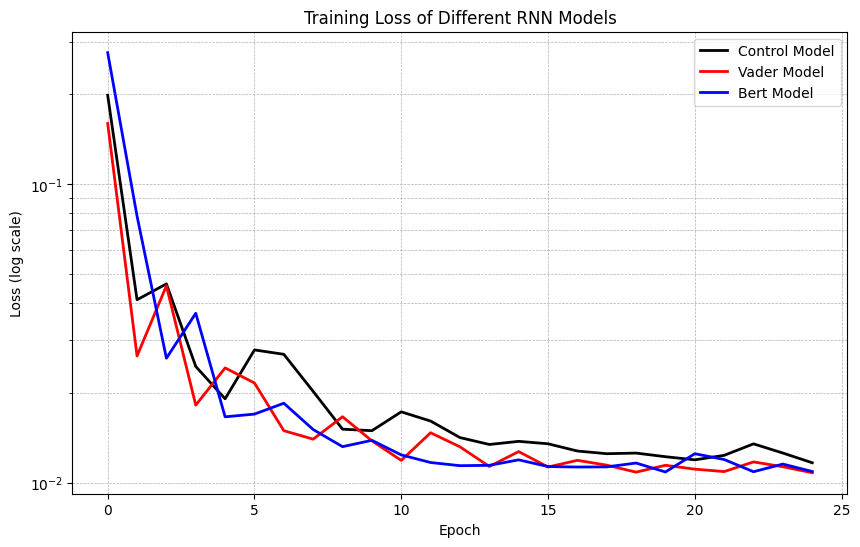

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step


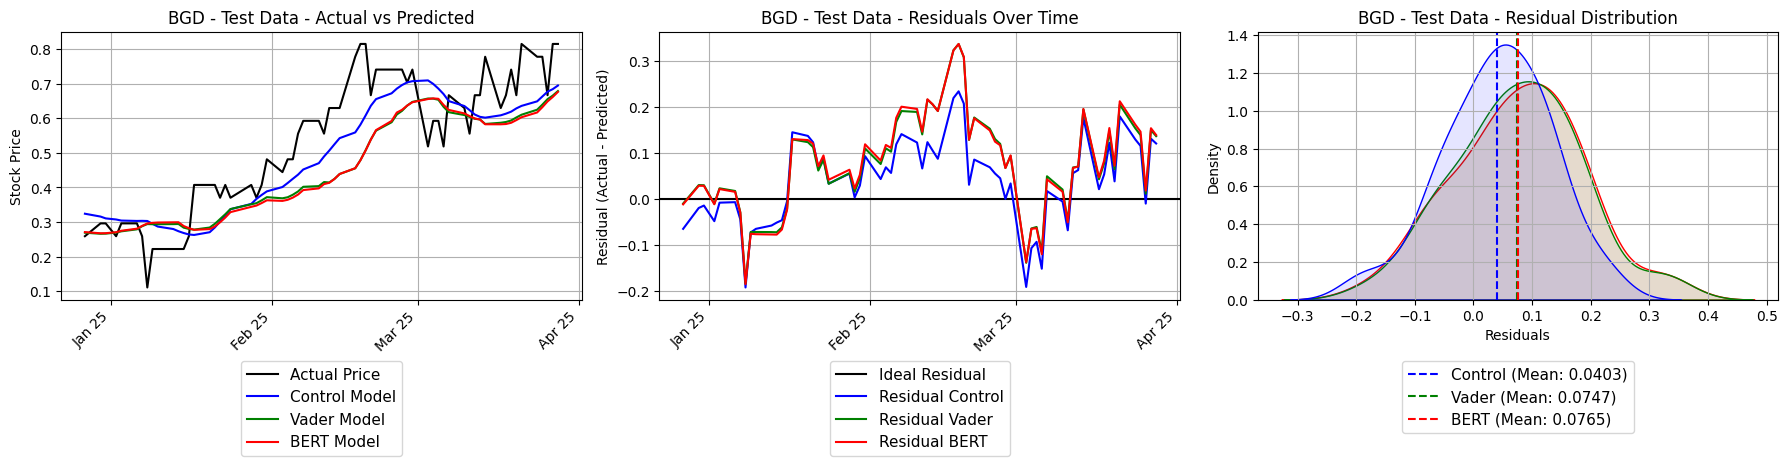

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 764ms/step - loss: 0.3645 - val_loss: 0.0110
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 601ms/step - loss: 0.0816 - val_loss: 0.0231
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 608ms/step - loss: 0.0410 - val_loss: 0.0361
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 638ms/step - loss: 0.0478 - val_loss: 0.0144
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 604ms/step - loss: 0.0175 - val_loss: 0.0068
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 962ms/step - loss: 0.0260 - val_loss: 0.0058
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 609ms/step - loss: 0.0287 - val_loss: 0.0064
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 618ms/step - loss: 0.0209 - val_loss: 0.0097
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 610ms/step - loss: 0.0156 - val_loss: 0.0154
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 609ms/step - loss: 0.0185 - val_loss: 0.0156
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 982ms/step - loss: 0.0192 - val_loss: 0.0098
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 686ms/step - loss: 0.0140 - val_loss: 0.0065


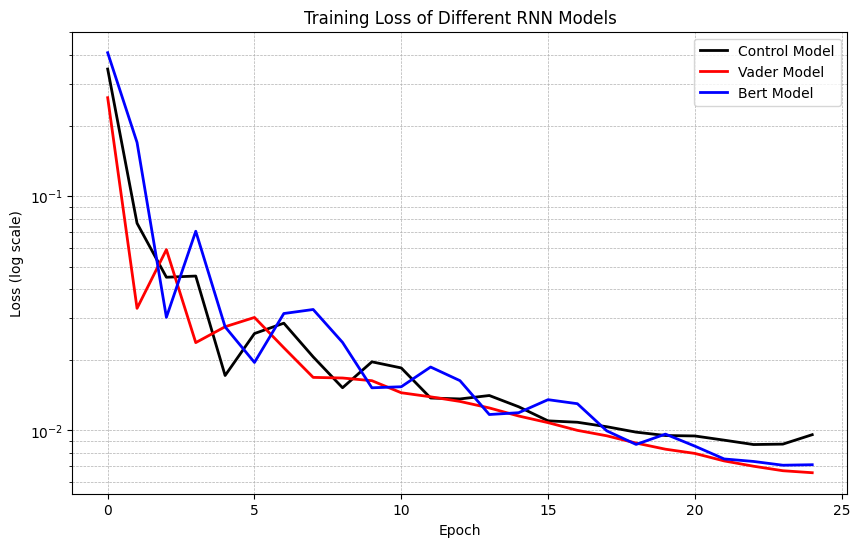

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


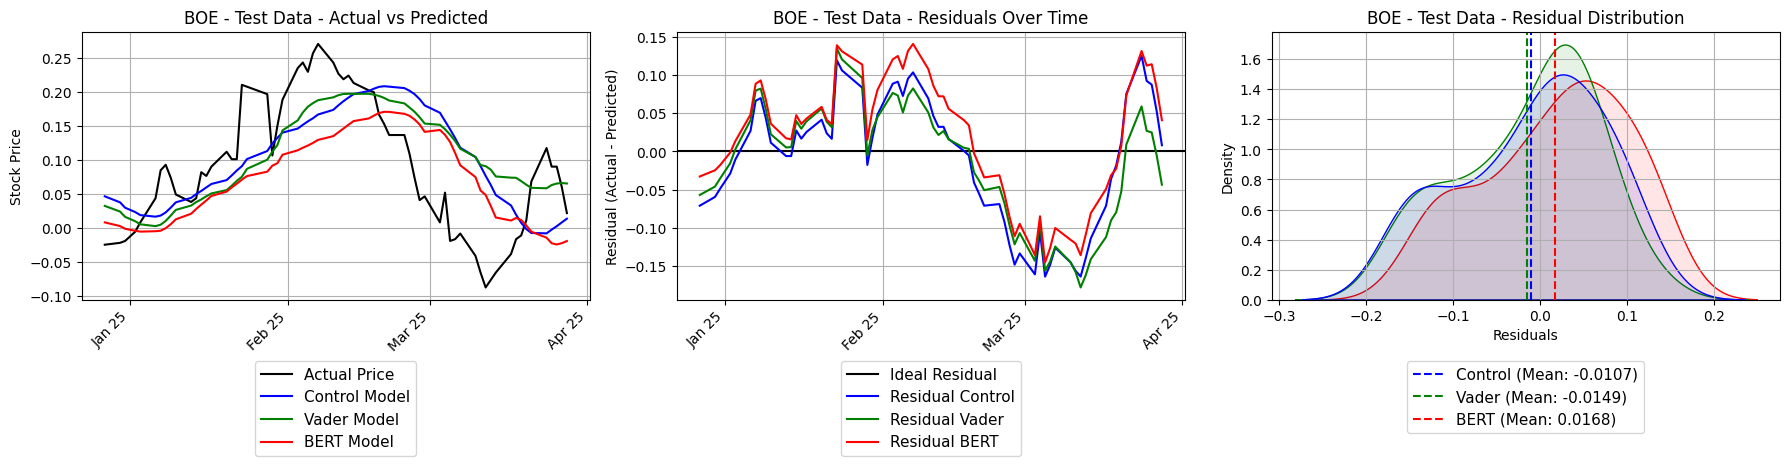

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 690ms/step - loss: 0.1028 - val_loss: 0.0016
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 632ms/step - loss: 0.0255 - val_loss: 0.0136
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 992ms/step - loss: 0.0105 - val_loss: 0.0172
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 617ms/step - loss: 0.0102 - val_loss: 0.0061
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 630ms/step - loss: 0.0049 - val_loss: 0.0028
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 629ms/step - loss: 0.0082 - val_loss: 0.0026
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 612ms/step - loss: 0.0066 - val_loss: 0.0042
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.0046 - val_loss: 0.0076
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 768ms/step - loss: 0.0052 - val_loss: 0.0074
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 627ms/step - loss: 0.0051 - val_loss: 0.0044
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 629ms/step - loss: 0.0034 - val_loss: 0.0026
Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 642ms/step - loss: 0.0780 - val_loss: 0.0044
Epoc

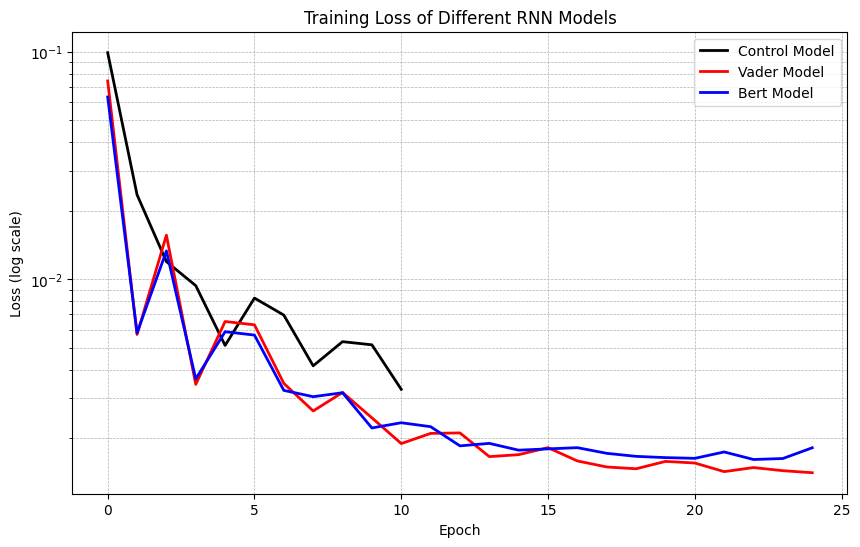

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


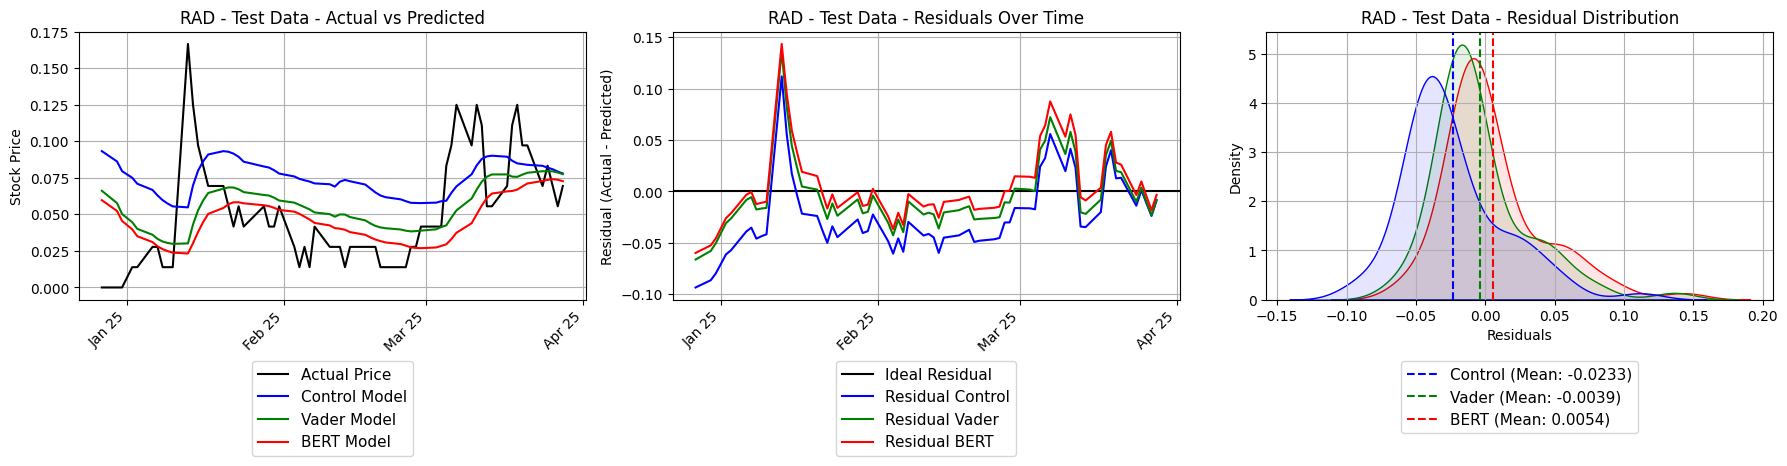

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 678ms/step - loss: 0.1342 - val_loss: 0.0016
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 613ms/step - loss: 0.0367 - val_loss: 0.0240
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 633ms/step - loss: 0.0402 - val_loss: 0.0178
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 983ms/step - loss: 0.0243 - val_loss: 0.0074
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 626ms/step - loss: 0.0183 - val_loss: 0.0033
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 607ms/step - loss: 0.0250 - val_loss: 0.0028
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 607ms/step - loss: 0.0238 - val_loss: 0.0047
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 605ms/step - loss: 0.0197 - val_loss: 0.0095
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 614ms/step - loss: 0.0172 - val_loss: 0.0113
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 974ms/step - loss: 0.0176 - val_loss: 0.0095
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 618ms/step - loss: 0.0154 - val_loss: 0.0074
Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 636ms/step - loss: 0.0723 - val_loss: 0.0060
E

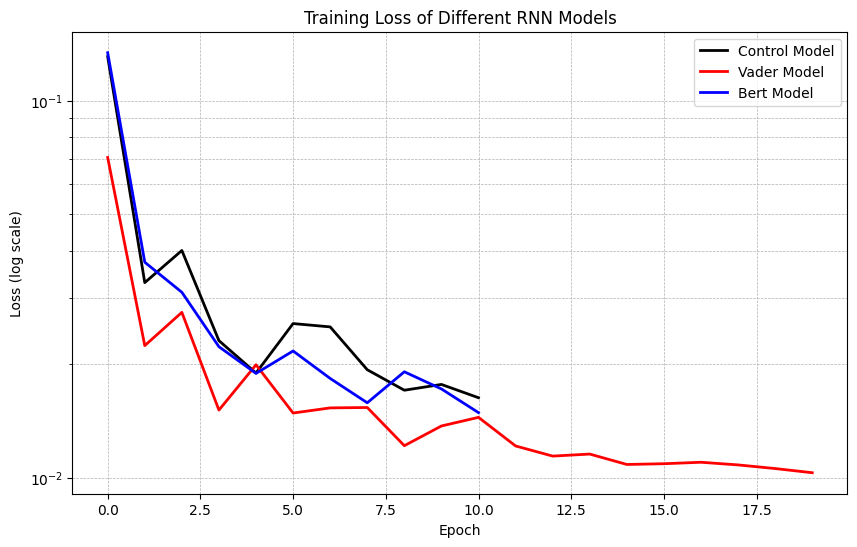

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


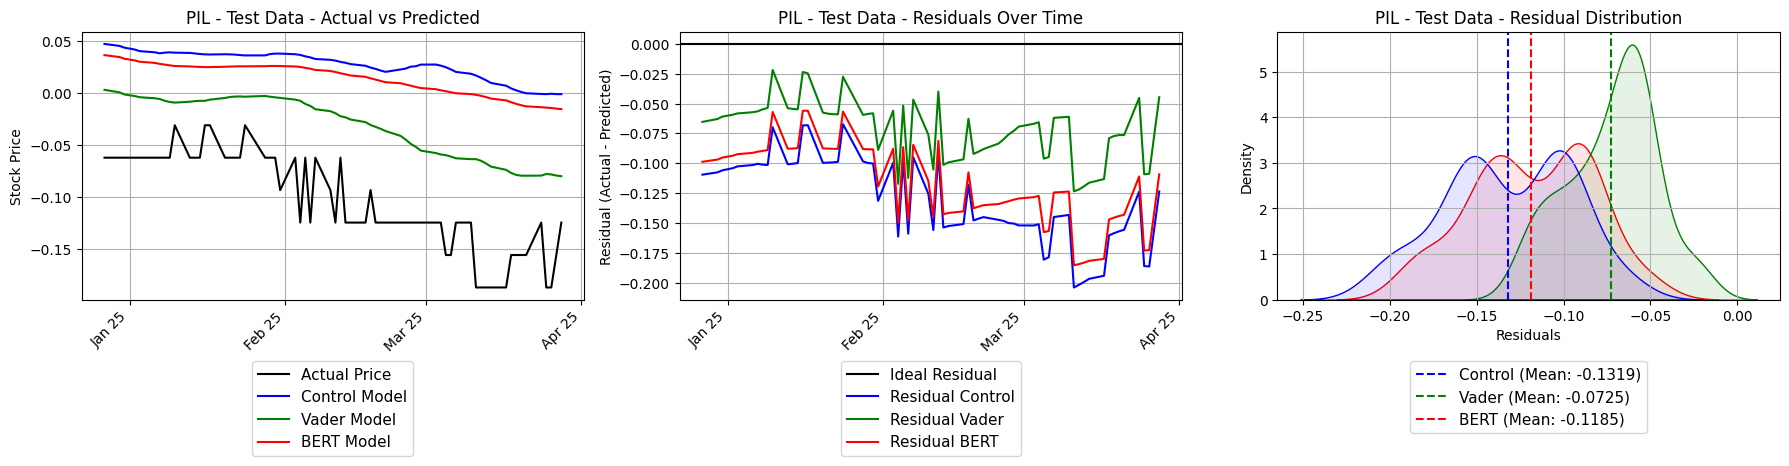

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.0500 - val_loss: 0.0262
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 630ms/step - loss: 0.0120 - val_loss: 0.0169
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 608ms/step - loss: 0.0091 - val_loss: 0.0387
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 608ms/step - loss: 0.0074 - val_loss: 0.0276
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 808ms/step - loss: 0.0066 - val_loss: 0.0107
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.0050 - val_loss: 0.0130
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 641ms/step - loss: 0.0052 - val_loss: 0.0104
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 621ms/step - loss: 0.0049 - val_loss: 0.0102
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 617ms/step - loss: 0.0046 - val_loss: 0.0099
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 981ms/step - loss: 0.0047 - val_loss: 0.0096
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 843ms/step - loss: 0.0044 - val_loss: 0.0095
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 618ms/step - loss: 0.0043 - val_loss: 0.0142
Epoch 

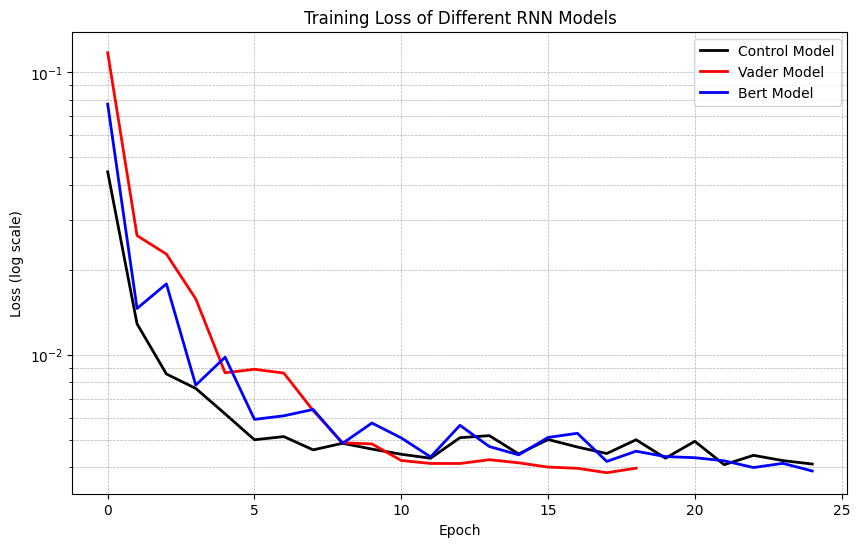

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


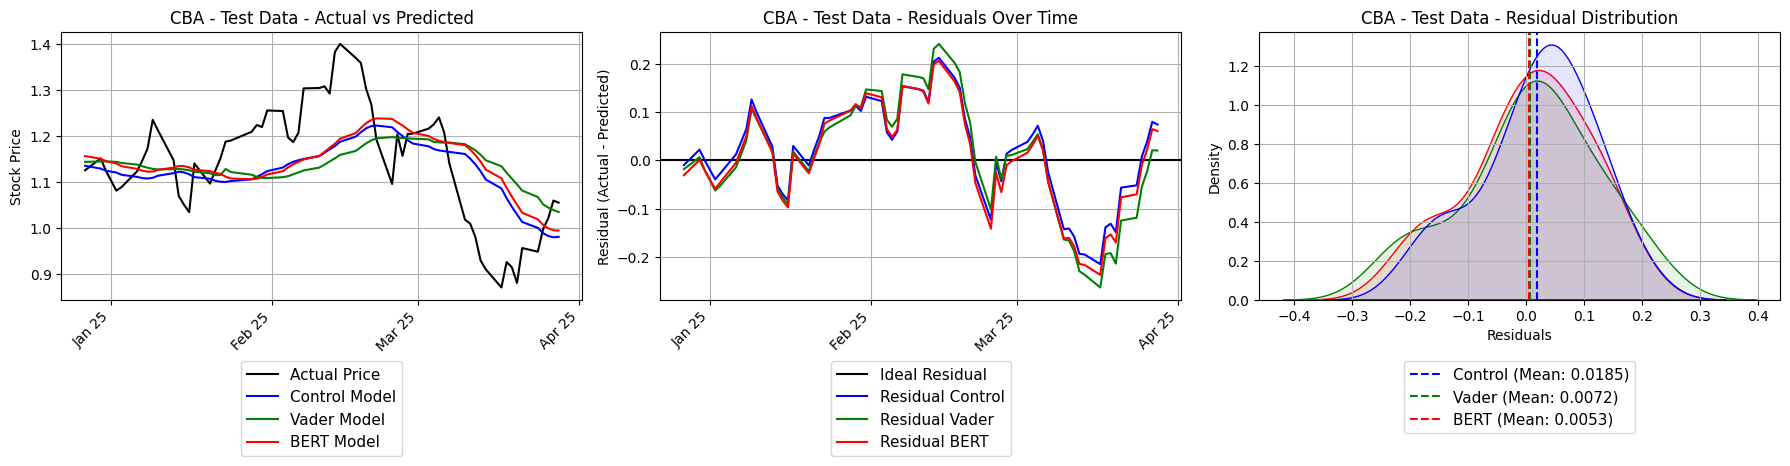

In [ ]:
max_epochs = 25
patience=10
BGD_df = train_and_evaluate_model('BGD', max_epochs=max_epochs, patience=patience) # mining
BOE_df = train_and_evaluate_model('BOE', max_epochs=max_epochs, patience=patience) # energy
RAD_df = train_and_evaluate_model('RAD', max_epochs=max_epochs, patience=patience) # healthcare
PIL_df = train_and_evaluate_model('PIL', max_epochs=max_epochs, patience=patience) # tech
CBA_df = train_and_evaluate_model('CBA', max_epochs=max_epochs, patience=patience) # banking

In [ ]:
performance_dfs = [BGD_df,BOE_df,RAD_df,PIL_df,CBA_df]
performance_summary = pd.concat(performance_dfs, axis=0, ignore_index=True)
performance_summary[['Model', 'Stock']] = performance_summary['Model'].str.split('_', expand=True)

pivoted_df = performance_summary.pivot(index='Model', columns='Stock', values='MSE')

pivoted_df = pivoted_df.loc[['Control', 'Vader', 'BERT']].reset_index()
pivoted_df

Stock,Model,BGD,BOE,CBA,PIL,RAD
0,Control,0.010008,0.006988,0.010436,0.018697,0.001870
1,Vader,0.016969,0.006399,0.014232,0.005896,0.001202
2,BERT,0.017634,0.006984,0.011358,0.015211,0.001345
